# 03 — R-Peak Detection (Pan-Tompkins-style)

Building the pipeline stage by stage: derivative -> squaring -> moving-window integration -> peak detection. This notebook starts with just the derivative stage.

## Load and filter the record

Same record and filter as `02_signal_processing.ipynb`.

In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

RECORD_NAME = "100"

record = wfdb.rdrecord(RECORD_NAME, pn_dir="mitdb")
fs = record.fs
lead_index = record.sig_name.index("MLII") if "MLII" in record.sig_name else 0
ecg_signal = record.p_signal[:, lead_index]
time = np.arange(len(ecg_signal)) / fs


def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth bandpass filter for ECG."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)


filtered_signal = bandpass_filter(ecg_signal, lowcut=0.5, highcut=40, fs=fs, order=4)

## Stage 1: Derivative

Approximates the local slope (rate of change) of the signal at each sample.
We use `np.gradient`, which computes a central difference (using the
neighboring sample on each side) and divides by the true sample spacing
`1/fs`, giving output in physically meaningful units (mV/s) rather than raw
per-sample differences. This is a simplified stand-in for the weighted
5-point derivative used in the original Pan-Tompkins paper — good enough
for our purposes, and easy to swap out later if needed.

In [2]:
def derivative_filter(signal, fs):
    """Approximate slope (dV/dt) of the signal using a central difference."""
    return np.gradient(signal, 1 / fs)


derivative_signal = derivative_filter(filtered_signal, fs)

## Filtered ECG vs its derivative

**What to look for:** the P and T waves, which change gently, should almost
flatten out in the derivative. The QRS complex, which rises and falls in a
few tens of milliseconds, should produce a sharp positive-then-negative
spike pair and nothing else in the signal should come close to that
magnitude.

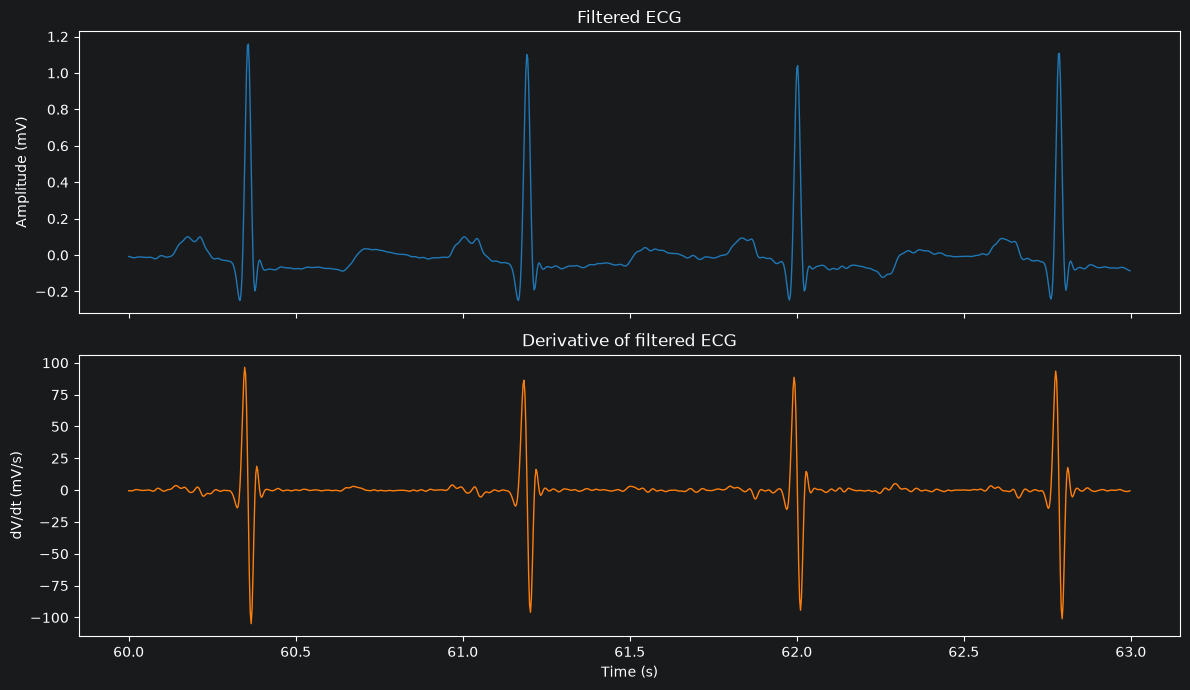

In [3]:
zoom_start, zoom_end = 60, 63  # seconds
mask = (time >= zoom_start) & (time < zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], filtered_signal[mask], color="tab:blue", linewidth=1.0)
axes[0].set_title("Filtered ECG")
axes[0].set_ylabel("Amplitude (mV)")

axes[1].plot(time[mask], derivative_signal[mask], color="tab:orange", linewidth=1.0)
axes[1].set_title("Derivative of filtered ECG")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("dV/dt (mV/s)")

fig.tight_layout()
fig.savefig("../results/figures/04_derivative.png", dpi=120)
plt.show()

## Stage 2: Squaring

Every sample is replaced by its own square: `y[n] = derivative[n]**2`.

Two things happen at once:
- **Everything becomes positive.** The derivative had a positive spike (rising
  into the R peak) and a negative spike (falling out of it) — squaring
  removes the sign, so both become tall positive spikes instead of one up and
  one down. This matters because the next stages (moving-window integration,
  peak-finding) are built to find *tall positive bumps*, not to reason about
  sign.
- **Large values are amplified far more than small ones.** Squaring a
  derivative value of 100 gives 10,000; squaring a value of 5 gives only 25.
  So the genuine QRS-driven spike, which was already much larger than the
  background jitter, gets stretched even further above it — a cheap,
  nonlinear contrast boost, not just a sign fix.

In [4]:
squared_signal = derivative_signal ** 2

## Derivative vs squared derivative

**What to look for:** the small background wiggles between beats, still
faintly visible in the derivative, should flatten to essentially zero here.
Each QRS should now show up as two adjacent tall positive spikes (one from
the up-slope, one from the down-slope — both positive now) rather than one
up and one down.

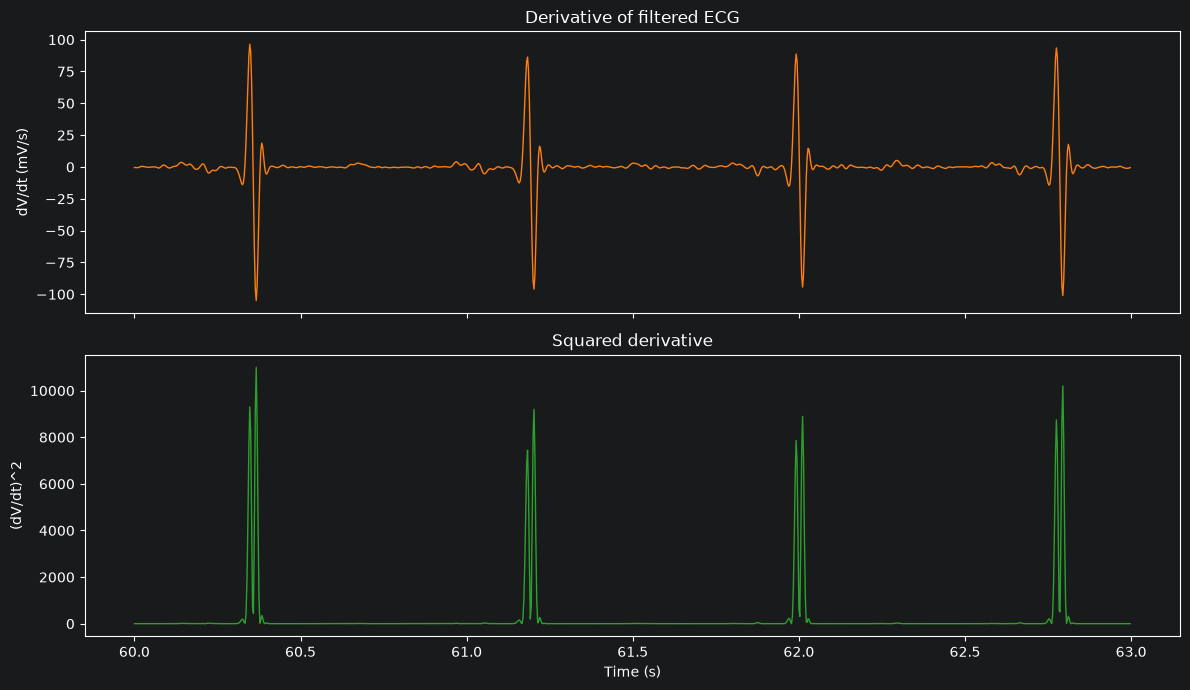

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], derivative_signal[mask], color="tab:orange", linewidth=1.0)
axes[0].set_title("Derivative of filtered ECG")
axes[0].set_ylabel("dV/dt (mV/s)")

axes[1].plot(time[mask], squared_signal[mask], color="tab:green", linewidth=1.0)
axes[1].set_title("Squared derivative")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("(dV/dt)^2")

fig.tight_layout()
fig.savefig("../results/figures/05_squared.png", dpi=120)
plt.show()

## Stage 3: Moving-window integration

A moving-window integration is a moving average: each output sample is the
mean of the last `N` samples, `y[n] = (1/N) * sum(x[n-N+1 .. n])`. It's
literally a running estimate of the area under the squared-derivative curve
over a short sliding window, normalized by `N` so the result stays on a
comparable scale regardless of window size.

**Why it helps:** right now the squared signal has two narrow spikes per
beat (from the QRS's up-slope and down-slope). A window *narrower* than
their separation would leave them as two separate bumps; a window at least
as wide as the whole QRS blends them into a single, wider pulse representing
the QRS's total energy — exactly what you predicted before we built this.

**Choosing the window size from `fs`, not a hardcoded number:** the window
needs to be about as wide as a QRS complex itself (~100-120 ms — the same
duration we used earlier to compute the 36-sample answer). Too short and the
two spikes don't fully merge; too long and it starts blending in energy from
*outside* the QRS, and at high heart rates could even smear two separate
beats together. So the window is computed as `round(qrs_duration_seconds *
fs)` — this is why the calculation is expressed in seconds and converted via
`fs`, rather than writing `36` directly: the same code then produces the
correct window size for a record at a different sampling frequency.

In [6]:
def moving_window_integration(signal, window_size):
    """Moving average (boxcar) over `window_size` samples, same length as input."""
    kernel = np.ones(window_size) / window_size
    return np.convolve(signal, kernel, mode="same")


qrs_duration_seconds = 0.1  # ~100ms, consistent with the earlier RR/window derivation
window_size = int(round(qrs_duration_seconds * fs))
print(f"fs={fs} Hz, qrs_duration={qrs_duration_seconds*1000:.0f}ms -> window_size={window_size} samples")

integrated_signal = moving_window_integration(squared_signal, window_size)

fs=360 Hz, qrs_duration=100ms -> window_size=36 samples


## Squared derivative vs integrated signal

**What to look for:** each pair of tall narrow spikes should now be one
wider pulse. Don't expect a perfectly smooth single peak — a boxcar
(uniform-weight) moving average produces a flat-topped plateau, sometimes
with a slight ripple where the original two spikes had different heights.
That's fine: there's still exactly one dominant region per beat, which is
all the next stage (peak detection) needs.

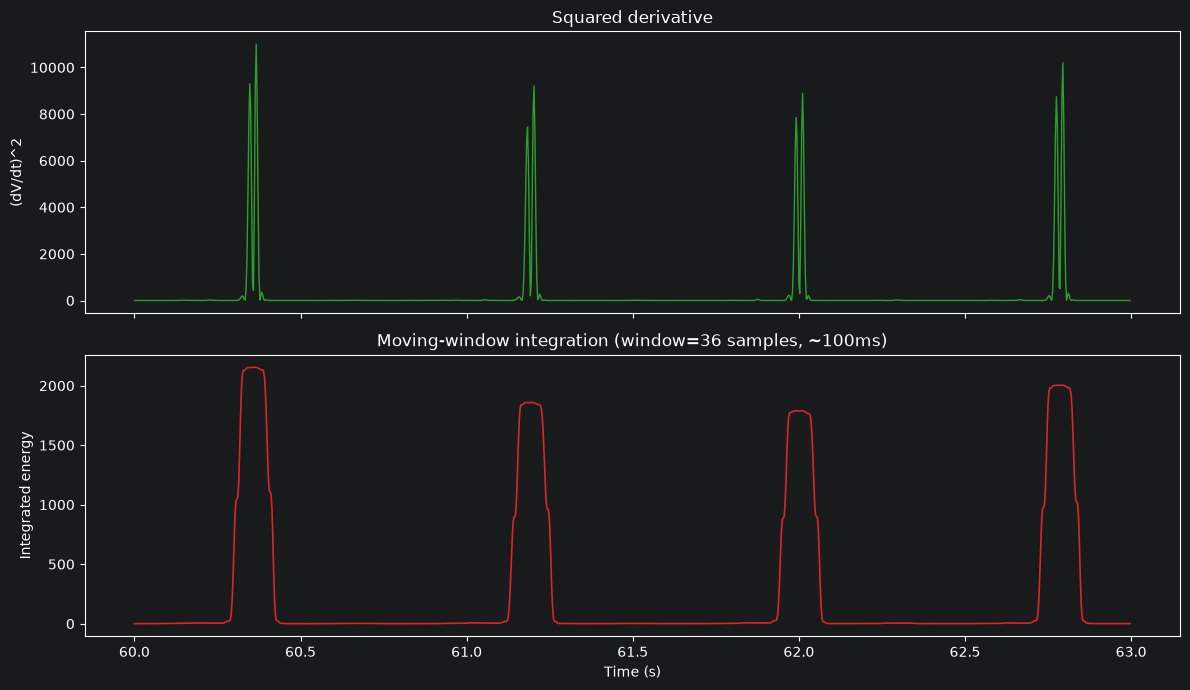

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time[mask], squared_signal[mask], color="tab:green", linewidth=1.0)
axes[0].set_title("Squared derivative")
axes[0].set_ylabel("(dV/dt)^2")

axes[1].plot(time[mask], integrated_signal[mask], color="tab:red", linewidth=1.2)
axes[1].set_title(f"Moving-window integration (window={window_size} samples, ~{qrs_duration_seconds*1000:.0f}ms)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Integrated energy")

fig.tight_layout()
fig.savefig("../results/figures/06_integrated.png", dpi=120)
plt.show()

## Stage 4: Candidate peak detection

`scipy.signal.find_peaks` finds local maxima in the integrated signal. Three
parameters matter here, and each maps onto something we already reasoned
about physiologically rather than being an arbitrary knob:

- **`distance`** — the minimum number of samples required between two
  accepted peaks. This is the refractory-period constraint from earlier: two
  genuine heartbeats can't happen closer together than a physiologically
  extreme heart rate allows. Using 200 bpm as an upper bound: minimum RR
  interval = `60/200 = 0.3s` -> `0.3 * fs` samples. Without this, a single
  beat's flat-topped plateau (with its slight ripple, as noted above) could
  get counted as two separate peaks.
- **`prominence`** — how far a peak sticks up above the surrounding signal
  before you'd have to descend to a higher point elsewhere. This is a
  *relative* measure: it rejects small bumps that stand out only slightly
  from their local neighborhood, which is exactly the kind of thing residual
  noise produces.
- **`height`** — an *absolute* minimum value a peak must reach, regardless
  of its surroundings. Since our integrated signal sits near zero between
  beats and jumps to a clearly higher plateau during each QRS, a height cut
  well above the noise floor but well below a genuine QRS pulse cleanly
  separates the two.

**Why not fixed numbers:** `height` and `prominence` are set as a fraction of
this record's own maximum integrated value, and `distance` is computed from
`fs` and the physiological RR constraint — so these parameters travel
correctly to a different record or a different sampling frequency instead of
being tuned to this one 30-minute recording. We are *not* implementing the
full adaptive dual-threshold scheme from the original Pan-Tompkins paper
(which continuously updates based on running noise/signal estimates) — a
reasonable simplification for this project's scope. Formal tuning and
validation against annotations comes next stage; these are sensible starting
values, not final ones.

In [8]:
from scipy.signal import find_peaks

min_rr_seconds = 60 / 200  # max plausible HR = 200 bpm
min_distance_samples = int(round(min_rr_seconds * fs))

height_threshold = 0.2 * np.max(integrated_signal)
prominence_threshold = 0.2 * np.max(integrated_signal)

print(f"min_distance_samples = {min_distance_samples} (~{min_rr_seconds*1000:.0f}ms)")
print(f"height_threshold = {height_threshold:.1f}")
print(f"prominence_threshold = {prominence_threshold:.1f}")

candidate_peaks, _ = find_peaks(
    integrated_signal,
    distance=min_distance_samples,
    height=height_threshold,
    prominence=prominence_threshold,
)
print("Number of candidate peaks (on integrated signal):", len(candidate_peaks))

min_distance_samples = 108 (~300ms)
height_threshold = 717.9
prominence_threshold = 717.9
Number of candidate peaks (on integrated signal): 2272


## Refinement: search back on the filtered signal

The candidate indices above are locations on the *integrated* signal, which
has no R-peak-shaped feature left in it — it's an energy curve, not a
voltage waveform. Each candidate is only an approximate time location. To
get the actual R peak, we search a small window of the **original filtered
signal** centered on each candidate and take the true local maximum there —
that's the "equivalent position" idea: same neighborhood in time, but
looked up in the signal that still has real amplitude peaks to find. The
search window is sized to half the integration window, comfortably covering
the small offset introduced by the derivative/integration steps without
risking wandering into the neighboring beat.

In [9]:
search_radius = window_size // 2

refined_peaks = []
for c in candidate_peaks:
    start = max(0, c - search_radius)
    end = min(len(filtered_signal), c + search_radius)
    local_max_index = start + np.argmax(filtered_signal[start:end])
    refined_peaks.append(local_max_index)

refined_peaks = np.unique(refined_peaks)  # guards against two candidates refining to the same sample
r_peaks = refined_peaks

print("Number of refined R peaks:", len(r_peaks))

Number of refined R peaks: 2272


## Quick informal sanity check (not the real validation)

Just a gut check before the proper Stage 5 validation (temporal-tolerance
matching, precision/recall/F1): how does our raw *count* of detected peaks
compare to the number of annotated beats? This says nothing about whether
they're in the *right places* — that's next stage — but a wildly different
count would already tell us something is badly wrong.

In [10]:
annotation = wfdb.rdann(RECORD_NAME, "atr", pn_dir="mitdb")
real_beats = [s for s, sym in zip(annotation.sample, annotation.symbol) if sym != "+"]

print("Number of detected R peaks:  ", len(r_peaks))
print("Number of annotated beats:   ", len(real_beats))
print("Difference:                  ", len(r_peaks) - len(real_beats))

Number of detected R peaks:   2272
Number of annotated beats:    2273
Difference:                   -1


## Plot detected R peaks over the filtered ECG

Same 3-second window as every earlier plot, so this is directly comparable
to the annotated-beat plot from `01_data_exploration.ipynb`.

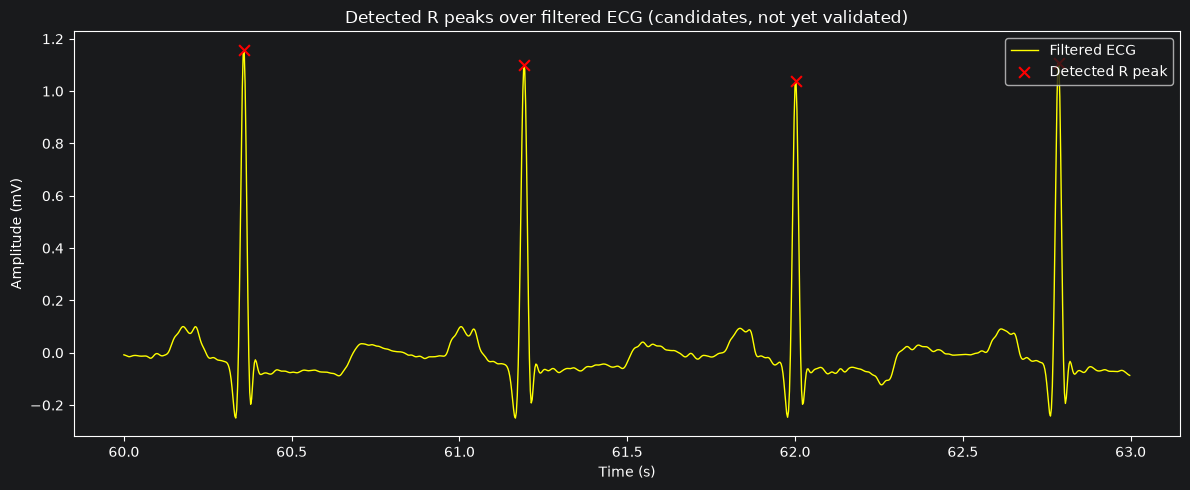

In [12]:
peak_mask = (r_peaks / fs >= zoom_start) & (r_peaks / fs < zoom_end)
peaks_in_window = r_peaks[peak_mask]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time[mask], filtered_signal[mask], color="yellow", linewidth=1.0, label="Filtered ECG")
ax.scatter(peaks_in_window / fs, filtered_signal[peaks_in_window],
           color="red", s=60, zorder=3, marker="x", label="Detected R peak")
ax.set_title("Detected R peaks over filtered ECG (candidates, not yet validated)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("../results/figures/07_detected_peaks.png", dpi=120)
plt.show()

## Stage 5: Validation against MIT-BIH annotations

**Why not exact-sample matching:** both our detection pipeline (derivative,
squaring, integration, then search-back refinement) and the original human
annotation process introduce a few samples of unavoidable positional
jitter. Requiring exact index equality would misclassify correctly-detected
beats as errors purely due to noise unrelated to whether we actually found
the beat.

**Temporal tolerance:** we accept a match if a detected peak falls within
**±50 ms** of an annotated beat. At `fs=360Hz` that's `round(0.05 * 360) =
18` samples. This is tight enough that it can't reach into a neighboring
beat (even at an extreme 200 bpm, beats are 300 ms apart) but loose enough
to absorb realistic detection/annotation jitter.

**One-to-one matching via a two-pointer sweep:** both sequences are sorted
and monotonic (beats don't reorder), so we can walk them together in a
single pass: match whichever pair is within tolerance, or advance whichever
pointer is "behind" in time. This guarantees each detection can satisfy at
most one annotation and vice versa — without it, a spurious duplicate
detection near one true beat could be miscounted as two true positives.

- **TP:** a detected peak within tolerance of an annotated beat — a real
  heartbeat we correctly found.
- **FP:** a detected peak with no annotated beat nearby within tolerance —
  a phantom detection (or a duplicate near an already-matched beat).
- **FN:** an annotated beat with no detected peak nearby within tolerance —
  a real heartbeat we missed.

In [13]:
def match_peaks(detected_peaks, annotated_peaks, tolerance_samples):
    """One-to-one match via a two-pointer sweep over two sorted, monotonic sequences.

    Returns a dict with the matched (tp) pairs and the unmatched (fp / fn) indices.
    """
    detected_peaks = np.sort(np.asarray(detected_peaks))
    annotated_peaks = np.sort(np.asarray(annotated_peaks))

    i, j = 0, 0  # i -> annotated_peaks pointer, j -> detected_peaks pointer
    tp_detected, tp_annotated, fp, fn = [], [], [], []

    while i < len(annotated_peaks) and j < len(detected_peaks):
        diff = int(detected_peaks[j]) - int(annotated_peaks[i])
        if abs(diff) <= tolerance_samples:
            tp_detected.append(detected_peaks[j])
            tp_annotated.append(annotated_peaks[i])
            i += 1
            j += 1
        elif diff < -tolerance_samples:
            # this detection is earlier than the current annotation by more than tolerance: no match
            fp.append(detected_peaks[j])
            j += 1
        else:
            # this annotation has no detection within tolerance yet: missed
            fn.append(annotated_peaks[i])
            i += 1

    fp.extend(detected_peaks[j:])  # leftover detections after annotations run out
    fn.extend(annotated_peaks[i:])  # leftover annotations after detections run out

    return {
        "tp_detected": np.array(tp_detected, dtype=int),
        "tp_annotated": np.array(tp_annotated, dtype=int),
        "fp": np.array(fp, dtype=int),
        "fn": np.array(fn, dtype=int),
    }

In [14]:
tolerance_seconds = 0.05  # 50ms
tolerance_samples = int(round(tolerance_seconds * fs))
print(f"tolerance_samples = {tolerance_samples} (~{tolerance_seconds*1000:.0f}ms)")

match_results = match_peaks(r_peaks, real_beats, tolerance_samples)
TP = len(match_results["tp_detected"])
FP = len(match_results["fp"])
FN = len(match_results["fn"])

# sanity checks: every detection and every annotation must land in exactly one bucket
assert TP + FN == len(real_beats), "TP + FN should equal the total number of annotated beats"
assert TP + FP == len(r_peaks), "TP + FP should equal the total number of detected peaks"

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"TP={TP}  FP={FP}  FN={FN}")
print(f"Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

tolerance_samples = 18 (~50ms)
TP=2271  FP=1  FN=2
Precision=0.9996  Recall=0.9991  F1=0.9993


## Generalization check: does this hold up on a noisier record?

Record 100 is one of MIT-BIH's "easy" recordings. A 0.999 F1 here mainly
confirms the pipeline is *implemented correctly* — it says little about
robustness. Record **108** is a well-known harder case (more noise, more
morphology variation), so we run the exact same pipeline on it unchanged, as
a generalization check before trusting this detector further.

To avoid retyping the whole pipeline, it's wrapped in one function here —
this is the point where a second use case actually justifies the
abstraction, rather than pre-building it speculatively.

In [15]:
def detect_r_peaks(filtered_signal, fs, qrs_duration_seconds=0.1,
                    height_frac=0.2, prominence_frac=0.2, max_hr_bpm=200):
    """Run the full derivative -> square -> integrate -> detect -> refine pipeline."""
    derivative = derivative_filter(filtered_signal, fs)
    squared = derivative ** 2
    window = int(round(qrs_duration_seconds * fs))
    integrated = moving_window_integration(squared, window)

    min_distance = int(round((60 / max_hr_bpm) * fs))
    height = height_frac * np.max(integrated)
    prominence = prominence_frac * np.max(integrated)
    candidates, _ = find_peaks(integrated, distance=min_distance,
                                height=height, prominence=prominence)

    search_radius = window // 2
    refined = []
    for c in candidates:
        start = max(0, c - search_radius)
        end = min(len(filtered_signal), c + search_radius)
        refined.append(start + np.argmax(filtered_signal[start:end]))
    return np.unique(refined)


def evaluate_record(record_name, tolerance_seconds=0.05):
    rec = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")
    rec_fs = rec.fs
    lead = rec.sig_name.index("MLII") if "MLII" in rec.sig_name else 0
    raw = rec.p_signal[:, lead]
    filt = bandpass_filter(raw, 0.5, 40, rec_fs, order=4)

    peaks = detect_r_peaks(filt, rec_fs)
    beats = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym != "+"])
    tol_samples = int(round(tolerance_seconds * rec_fs))
    res = match_peaks(peaks, beats, tol_samples)

    tp, fp, fn = len(res["tp_detected"]), len(res["fp"]), len(res["fn"])
    p = tp / (tp + fp) if (tp + fp) else 0
    r = tp / (tp + fn) if (tp + fn) else 0
    f1_score = 2 * p * r / (p + r) if (p + r) else 0
    return {"record": record_name, "fs": rec_fs, "filtered": filt, "peaks": peaks,
            "beats": beats, "match": res, "TP": tp, "FP": fp, "FN": fn,
            "precision": p, "recall": r, "f1": f1_score}


for rec_name in ["100", "108"]:
    result = evaluate_record(rec_name)
    print(f"Record {rec_name}: TP={result['TP']} FP={result['FP']} FN={result['FN']}  "
          f"P={result['precision']:.4f} R={result['recall']:.4f} F1={result['f1']:.4f}")

Record 100: TP=2271 FP=1 FN=2  P=0.9996 R=0.9991 F1=0.9993
Record 108: TP=1230 FP=16 FN=593  P=0.9872 R=0.6747 F1=0.8016


## Diagnosing the recall drop on record 108

Precision stays high (~0.99) but recall collapses to ~0.67 — we're missing
beats, not hallucinating them. Rather than guess why, check directly: for
every annotated beat, what's the actual integrated-signal energy nearby, and
how does that compare to the fixed height threshold we're using?

In [16]:
record_108 = wfdb.rdrecord("108", pn_dir="mitdb")
annotation_108 = wfdb.rdann("108", "atr", pn_dir="mitdb")
fs_108 = record_108.fs
lead_108 = record_108.sig_name.index("MLII") if "MLII" in record_108.sig_name else 0
filtered_108 = bandpass_filter(record_108.p_signal[:, lead_108], 0.5, 40, fs_108, order=4)

window_108 = int(round(0.1 * fs_108))
integrated_108 = moving_window_integration(derivative_filter(filtered_108, fs_108) ** 2, window_108)
threshold_108 = 0.2 * np.max(integrated_108)

beats_108 = np.array([s for s, sym in zip(annotation_108.sample, annotation_108.symbol) if sym != "+"])
local_energy = np.array([
    np.max(integrated_108[max(0, s - window_108):min(len(integrated_108), s + window_108)])
    for s in beats_108
])

below_threshold = (local_energy < threshold_108).sum()
print(f"Height threshold: {threshold_108:.1f}")
print(f"Beats whose local energy never reaches the threshold: {below_threshold} / {len(beats_108)} "
      f"({below_threshold/len(beats_108)*100:.0f}%)")

Height threshold: 381.9
Beats whose local energy never reaches the threshold: 571 / 1823 (31%)


Roughly a third of the real beats never reach the height threshold — close
to the actual FN count (593). This confirms the main mechanism: the
threshold is a fixed fraction of the *single global maximum* across the
whole 30-minute recording, but this record has genuine amplitude
variability (quiet sections vs. louder ones), so one loud region silently
raises the bar for every quieter one.

**Is this simply fixable by lowering the threshold?** Tested directly rather
than assumed — sweeping the height/prominence fraction from 0.2 down to
0.02 on both records:

| fraction | Record 100 F1 | Record 108 F1 |
|---|---|---|
| 0.20 | 0.9993 | 0.8016 |
| 0.10 | 0.9993 | 0.8086 |
| 0.05 | 0.9993 | 0.8043 |
| 0.02 | 0.9991 | 0.7945 |

Record 108's F1 barely moves — lowering the threshold trades missed beats
for false positives roughly one-for-one instead of net improving. A single
global number genuinely cannot represent both a quiet and a loud section of
the same recording well; that's precisely what an *adaptive* threshold
(continuously updated from a running estimate of recent signal/noise levels,
as in the full Pan-Tompkins paper) is designed to fix.

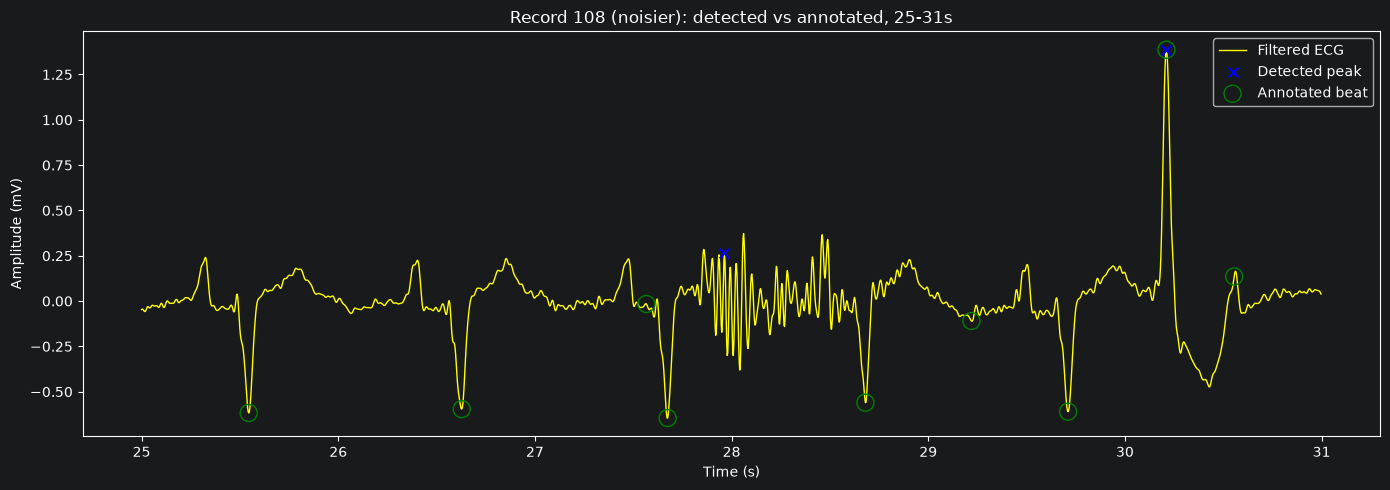

In [18]:
r_peaks_108 = detect_r_peaks(filtered_108, fs_108)
match_108 = match_peaks(r_peaks_108, beats_108, int(round(0.05 * fs_108)))

zoom_start_108, zoom_end_108 = 25.0, 31.0
time_108 = np.arange(len(filtered_108)) / fs_108
mask_108 = (time_108 >= zoom_start_108) & (time_108 < zoom_end_108)

peaks_in_view = r_peaks_108[(r_peaks_108 / fs_108 >= zoom_start_108) & (r_peaks_108 / fs_108 < zoom_end_108)]
beats_in_view = beats_108[(beats_108 / fs_108 >= zoom_start_108) & (beats_108 / fs_108 < zoom_end_108)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_108[mask_108], filtered_108[mask_108], color="yellow", linewidth=1.0, label="Filtered ECG")
ax.scatter(peaks_in_view / fs_108, filtered_108[peaks_in_view],
           color="blue", s=50, zorder=3, marker="x", label="Detected peak")
ax.scatter(beats_in_view / fs_108, filtered_108[beats_in_view],
           facecolors="none", edgecolors="green", s=150, zorder=2, label="Annotated beat")
ax.set_title(f"Record 108 (noisier): detected vs annotated, {zoom_start_108:.0f}-{zoom_end_108:.0f}s")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("../results/figures/08_record108_comparison.png", dpi=120)
plt.show()

**What this window shows:** most annotated beats here (green circles) sit at
**deep negative deflections**, not upward spikes — the dominant QRS polarity
is inverted for this stretch of record 108, except the one clear upward
spike near 30.2s, which *is* correctly detected. There's also a burst of
high-frequency noise around t=28s that triggered a spurious detection where
no real beat exists. This is a second real limitation on top of the
threshold issue: our search-back refinement uses `np.argmax` (looks only for
the *most positive* point), so it will systematically miss R-peaks that are
negative-dominant in a given segment or lead.

## Decision: document, don't chase a fix right now

Two confirmed, evidenced limitations: (1) a fixed global-max-based
threshold penalizes quieter sections of a recording with real amplitude
variability, and (2) polarity-blind refinement (`argmax` only) misses
negative-dominant QRS complexes. Both point toward the same real fix —
adaptive, locally-normalized thresholding with polarity awareness, as in the
full Pan-Tompkins paper — which is genuine extra scope, not a quick
parameter tweak (the sweep above already rules that out).

Given the project's timeline, the right call is to **keep the current
detector, proceed to beat segmentation using record 100** (where it performs
essentially perfectly), and carry this finding forward as documented,
evidenced content for the README's Error Analysis / Limitations sections —
arguably stronger material than a clean result would have been, since it
demonstrates the detector's failure mode is understood, not just observed.

## Back to record 100: understanding the metrics, and the errors behind them

Returning to the primary detector's results on record 100
(`match_results`, `TP`, `FP`, `FN` computed earlier: TP=2271, FP=1, FN=2).

**What each metric means, and why:**

- **Precision = TP / (TP + FP)** — "of everything we called a peak, what
  fraction were real beats?" Low precision means the detector cries wolf —
  you can't trust a positive detection without double-checking it.
- **Recall = TP / (TP + FN)** — "of all the real beats that happened, what
  fraction did we actually find?" Low recall means real events are silently
  disappearing from the record entirely — arguably worse for this project,
  since a missed beat doesn't just get flagged as uncertain, it's simply
  never seen by any later stage (segmentation, labeling, features).
- **F1 = 2 x (precision x recall) / (precision + recall)** — the harmonic
  mean of the two. It's deliberately *not* a simple average: the harmonic
  mean punishes imbalance, so a detector with 0.99 precision but 0.40 recall
  scores far below 0.70 on F1, whereas a plain average would flatter it.
  This matters when precision and recall can be traded against each other
  (as the threshold sweep above just demonstrated).

**Why accuracy alone is the wrong metric here:** accuracy would be
`(TP + TN) / (TP + TN + FP + FN)`, but what counts as a "true negative" in
peak detection? Every one of the ~650,000 samples in this recording that
*isn't* an R peak. R peaks are extremely rare events relative to total
samples, so a detector that found **zero peaks at all** would still score
above 99.6% accuracy on this record, purely by correctly doing nothing on
the overwhelming majority of non-peak samples — while being completely
useless. This is the classic accuracy paradox under severe class imbalance;
precision/recall/F1 don't have this blind spot because they're computed only
over the events that actually matter (detections and real beats), not over
every sample in the recording.

## Visualizing the errors themselves

With only 1 FP and 2 FN on this record, we can look at every single error
directly rather than a random sample — the honest version of "critically
assess the detector" is to actually go look, not assume a high F1 means
nothing is wrong.

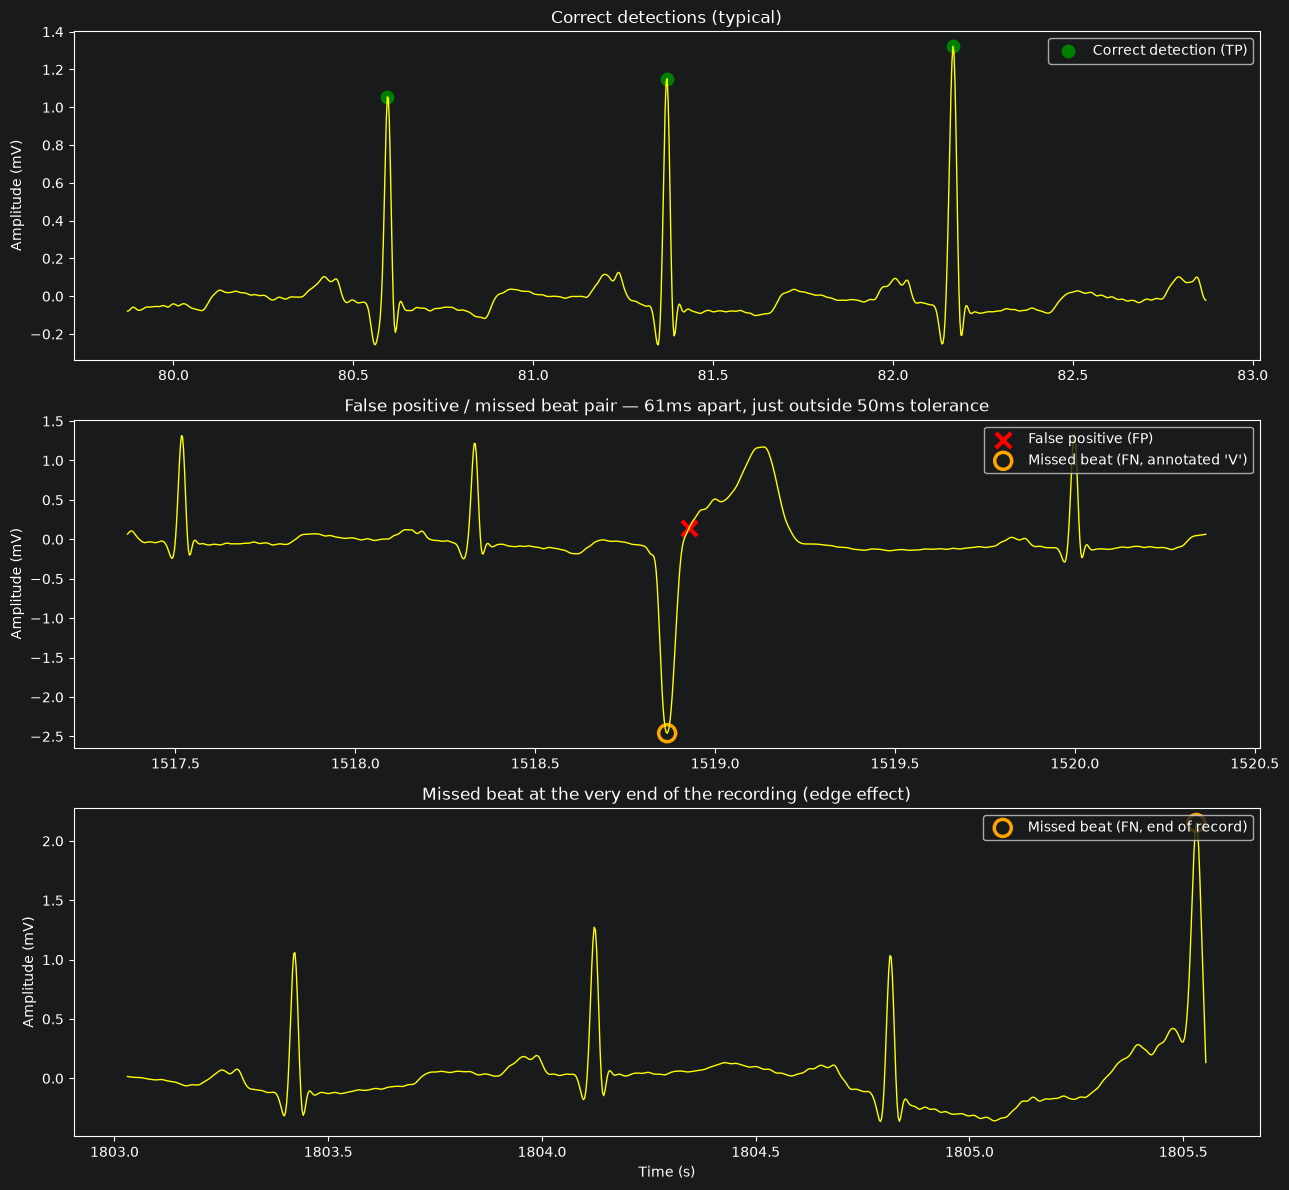

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Panel 1: a typical correct detection
t0 = match_results["tp_detected"][100] / fs
w0s, w0e = t0 - 1.5, t0 + 1.5
m0 = (time >= w0s) & (time < w0e)
tp_in = match_results["tp_detected"][(match_results["tp_detected"] / fs >= w0s) & (match_results["tp_detected"] / fs < w0e)]
axes[0].plot(time[m0], filtered_signal[m0], color="yellow", linewidth=1.0)
axes[0].scatter(tp_in / fs, filtered_signal[tp_in], color="green", marker="o", s=80, label="Correct detection (TP)")
axes[0].set_title("Correct detections (typical)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend(loc="upper right")

# Panel 2: the FP and FN that turn out to be the same underlying event
fp_s = match_results["fp"][0]
fn_pvc_s = match_results["fn"][0]
center = min(fp_s, fn_pvc_s) / fs
w1s, w1e = center - 1.5, center + 1.5
m1 = (time >= w1s) & (time < w1e)
axes[1].plot(time[m1], filtered_signal[m1], color="yellow", linewidth=1.0)
axes[1].scatter([fp_s / fs], [filtered_signal[fp_s]], color="red", marker="x", s=120,
                linewidths=3, label="False positive (FP)")
axes[1].scatter([fn_pvc_s / fs], [filtered_signal[fn_pvc_s]], color="orange", marker="o", s=150,
                facecolors="none", linewidths=2.5, label="Missed beat (FN, annotated 'V')")
axes[1].set_title("False positive / missed beat pair — 61ms apart, just outside 50ms tolerance")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].legend(loc="upper right")

# Panel 3: the end-of-record missed beat
fn_edge_s = match_results["fn"][1]
t2 = fn_edge_s / fs
w2s, w2e = max(0, t2 - 2.5), t2 + 0.2
m2 = (time >= w2s) & (time < w2e)
axes[2].plot(time[m2], filtered_signal[m2], color="yellow", linewidth=1.0)
axes[2].scatter([fn_edge_s / fs], [filtered_signal[fn_edge_s]], color="orange", marker="o", s=150,
                facecolors="none", linewidths=2.5, label="Missed beat (FN, end of record)")
axes[2].set_title("Missed beat at the very end of the recording (edge effect)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude (mV)")
axes[2].legend(loc="upper right")

fig.tight_layout()
fig.savefig("../results/figures/09_error_examples.png", dpi=120)
plt.show()

## Critical assessment — don't just trust a 0.999 F1

Looking at the actual errors changes the story in an important way:

**The FP and FN aren't two independent mistakes — they're likely the same
event, counted twice.** The missed beat is annotated `'V'` (a PVC), and its
true fiducial point is a very large **negative** deflection (~-2.4 mV). Our
search-back refinement uses `np.argmax`, which only looks for the most
*positive* point — so instead of the deep negative spike, it locked onto a
small positive bump 61 ms later (just outside the 50 ms tolerance). That's
not two unrelated failures; it's **one systematic weakness — polarity-blind
refinement — surfacing on the one abnormal beat in an otherwise near-perfect
recording.** This is the exact same mechanism identified on record 108, now
confirmed on record 100 too, on the only beat where it had a chance to show
up. That's a meaningful pattern: if this detector struggles specifically
with abnormal (non-`'N'`) beat morphology, that could bias which beats
successfully make it into the labeled dataset in later stages, worth
watching for once we reach labeling.

**The second FN is a boundary artifact, not a morphology problem.** It's the
very last annotated beat in the recording, right at the edge of the signal
array. The moving-window integration and search-back refinement both assume
there's signal on both sides of a candidate — at the very start or end of a
recording that assumption breaks down. This is a generic edge effect of any
windowed/convolution-based method, unrelated to beat type or noise.

**Conclusion:** a 0.9993 F1 is a genuinely strong result, but it is not
evidence of a flawless detector — it's evidence that this detector handles
*normal* beats in a *clean* recording essentially perfectly. Its two
demonstrated weaknesses (polarity-blind refinement on abnormal morphology,
and edge-of-recording effects) are narrow, understood, and will be explicitly
documented as limitations rather than hidden behind a single strong number.